Kształt X_f: (100, 10)
Kształt X_mi: (100, 10)
Kształt y: (100,)


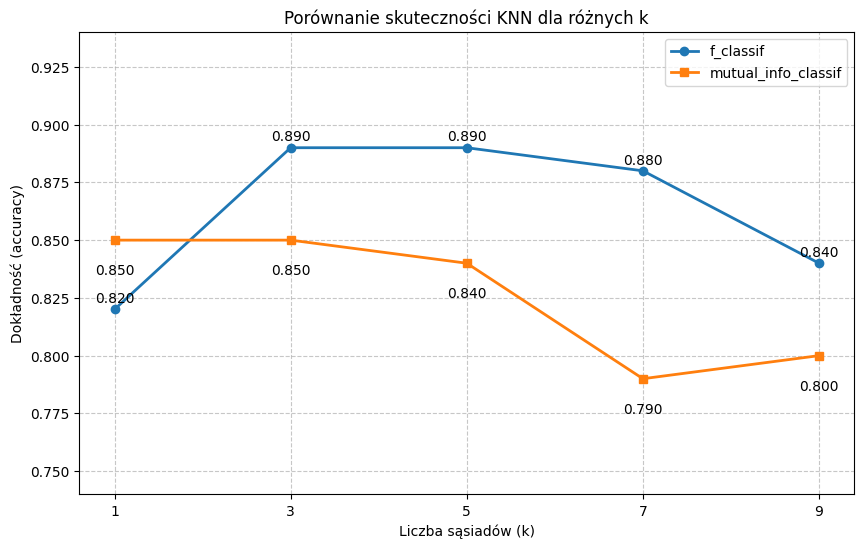

Najlepsze wyniki:
f_classif → k=3, accuracy=0.8900
mutual_info_classif → k=1, accuracy=0.8500


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Generowanie syntetycznego zbioru danych
X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=5,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Selekcja cech za pomocą f_classif
selector_f = SelectKBest(score_func=f_classif, k=10)
X_f = selector_f.fit_transform(X, y)

# Selekcja cech za pomocą mutual_info_classif
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10)
X_mi = selector_mi.fit_transform(X, y)

print(f"Kształt X_f: {X_f.shape}")
print(f"Kształt X_mi: {X_mi.shape}")
print(f"Kształt y: {y.shape}")

# Zakres wartości k do przetestowania
k_values = [1, 3, 5, 7, 9]

# Przechowywanie dokładności
accuracies_f = []
accuracies_mi = []

# Lepsza walidacja dla klasyfikacji
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test dla każdego k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # f_classif
    scores_f = cross_val_score(knn, X_f, y, cv=cv, scoring='accuracy')
    accuracies_f.append(scores_f.mean())

    # mutual_info_classif
    scores_mi = cross_val_score(knn, X_mi, y, cv=cv, scoring='accuracy')
    accuracies_mi.append(scores_mi.mean())

# Wykres porównawczy
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies_f, marker='o', linewidth=2, label='f_classif')
plt.plot(k_values, accuracies_mi, marker='s', linewidth=2, label='mutual_info_classif')

plt.xlabel("Liczba sąsiadów (k)")
plt.ylabel("Dokładność (accuracy)")
plt.title("Porównanie skuteczności KNN dla różnych k")
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Dynamiczny zakres osi Y
all_accuracies = accuracies_f + accuracies_mi
y_min = max(0, min(all_accuracies) - 0.05)
y_max = min(1.0, max(all_accuracies) + 0.05)
plt.ylim(y_min, y_max)

# Opcjonalnie: podpisy punktów
for x, y_val in zip(k_values, accuracies_f):
    plt.text(x, y_val + 0.003, f"{y_val:.3f}", ha='center')

for x, y_val in zip(k_values, accuracies_mi):
    plt.text(x, y_val - 0.015, f"{y_val:.3f}", ha='center')

plt.show()

# Wypisz najlepsze wyniki
best_k_f = k_values[np.argmax(accuracies_f)]
best_acc_f = np.max(accuracies_f)

best_k_mi = k_values[np.argmax(accuracies_mi)]
best_acc_mi = np.max(accuracies_mi)

print("Najlepsze wyniki:")
print(f"f_classif → k={best_k_f}, accuracy={best_acc_f:.4f}")
print(f"mutual_info_classif → k={best_k_mi}, accuracy={best_acc_mi:.4f}")